# **Bitcoin Price Prediction: Data Preprocessing & Exploratory Data Analysis (EDA)**
This notebook serves as the initial, critical phase of our Bitcoin Price Prediction project. Before feeding data into any machine learning or deep learning models, we must ensure our dataset is clean, well-understood, and properly structured.
---
## 🛠️ What This Notebook Does
###Data Cleaning
###Exploratory Data Analysis (EDA)
###Feature Engineering
---

## 🧱 Phase 1: Environment Setup & Data Loading

In this initial section, we set up our workspace, establish a connection to our storage, and load the raw Bitcoin dataset to inspect its structure.

---

### 1. Library Imports
We import the essential Python libraries required for data manipulation, visualization, and scaling:
* `pandas` & `numpy`: For data manipulation and numerical operations.
* `matplotlib.pyplot` & `seaborn`: For creating exploratory data visualizations.
* `RobustScaler`: To eventually scale our features while handling potential market outliers.

### 2. Google Drive Mounting
Since our dataset is stored in Google Drive, we connect the Colab environment to our personal drive storage using `drive.mount()`. This allows us to read the data file directly without manual uploads.

### 3. Loading the Dataset
We load our raw Bitcoin daily data (`btc_1d_data_2018_to_2025.csv`) into a Pandas DataFrame (`df`). The dataset spans multiple years of OHLCV (Open, High, Low, Close, Volume) data along with transaction metrics.

### 4. Initial Data Inspection
To verify the data loaded correctly and to get a first look at the structure, we inspect the boundaries of the dataset:
* `df.head(3)`: Displays the first 3 rows, showing data starting from **January 1, 2018**.
* `df.tail(3)`: Displays the last 3 rows, showing data extending up to **March 14, 2026**.

This confirms we have a continuous time series dataset consisting of **2,995 total rows** (indexed from 0 to 2994).

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import RobustScaler
from google.colab import files

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
file_path = "/content/drive/MyDrive/Colab Notebooks/Bitcoin_Project/btc_1d_data_2018_to_2025.csv"
df = pd.read_csv(file_path)
df.head(3)

,Open time,Open,High,Low,Close,Volume,Close time,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume,Ignore
0,2018-01-01 00:00:00.000000 UTC,13715.65,13818.55,12750.00,13380.00,8609.915844,2018-01-01 23:59:59.999000 UTC,1.147997e+08,105595,3961.938946,5.280975e+07,0
1,2018-01-02 00:00:00.000000 UTC,13382.16,15473.49,12890.02,14675.11,20078.092111,2018-01-02 23:59:59.999000 UTC,2.797171e+08,177728,11346.326739,1.580801e+08,0
2,2018-01-03 00:00:00.000000 UTC,14690.00,15307.56,14150.00,14919.51,15905.667639,2018-01-03 23:59:59.999000 UTC,2.361169e+08,162787,8994.953566,1.335873e+08,0


In [ ]:
df.tail(3)

,Open time,Open,High,Low,Close,Volume,Close time,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume,Ignore
2994,2026-03-14 00:00:00.000000 UTC,70930.01,70951.80,70481.70,70880.82,1319.87590,2026-03-14 23:59:59.999000 UTC,9.334740e+07,155788,517.07453,3.658056e+07,0
2995,2026-03-15 00:00:00.000000 UTC,71211.95,71252.31,70858.82,71250.68,1078.37451,2026-03-15 23:59:59.999000 UTC,7.663180e+07,142918,488.02938,3.469304e+07,0
2996,2026-03-16 00:00:00.000000 UTC,72815.25,73008.94,72270.41,72750.01,1420.46734,2026-03-16 23:59:59.999000 UTC,1.031521e+08,377340,710.92168,5.162422e+07,0


## 🧹 Phase 2: Structural Cleaning & Data Type Conversion

In this step, we clean up the dataset's structure by removing unnecessary information, standardizing the column names, and ensuring every feature has the correct data type for machine learning models.

---

### 1. Removing Unnecessary Columns
We drop columns like `Close time` and `Ignore` that do not add predictive value to our Bitcoin model. This reduces clutter and saves memory.

### 2. Standardizing Column Names
To make our code cleaner and prevent errors down the line, we format the column text by:
* Replacing spaces with underscores (`_`).
* Converting all column names to lowercase.
* *Resulting columns include:* `open_time`, `open`, `high`, `low`, `close`, `volume`, and transaction metrics.

### 3. Data Type Conversions
For proper mathematical modeling and chronological sorting, we enforce explicit data types across the dataset:
* **Datetime Conversion:** We convert `open_time` from a generic string/object type into a proper `datetime` object using `pd.to_datetime()`.
* **Floating-Point Scaling:** We cast the core market price, volume, and asset features (like `open`, `high`, `low`, `close`, `volume`, etc.) into decimals (`float`).
* **Integer Formatting:** We convert the total counts, specifically `number_of_trades`, into whole numbers (`int`).

In [ ]:
#Drop Junk columns
columns_to_drop =['Close time','Ignore']
df.drop(columns=columns_to_drop,axis=1,inplace=True)
#Replace spaces and convert tow lowercase
df.columns = df.columns.str.replace(' ','_').str.lower()
print(df.columns)

Index(['open_time', 'open', 'high', 'low', 'close', 'volume',
       'quote_asset_volume', 'number_of_trades', 'taker_buy_base_asset_volume',
       'taker_buy_quote_asset_volume'],
      dtype='object')


In [ ]:
#Types Conversions
#datetime conversion
df['open_time']=pd.to_datetime(df['open_time'])
#numeric flaot columns
float_cols = ['open','high','low','close','volume','quote_asset_volume',
              'taker_buy_base_asset_volume',
              'taker_buy_quote_asset_volume']
df[float_cols]=df[float_cols].astype(float)
#integer column
df['number_of_trades']=df['number_of_trades'].astype(int)

## 🔍 Phase 3: Exploratory Data Analysis (EDA) — Stage 1: Basic Integrity Check

Before analyzing market patterns or trends, we must ensure our baseline dataset is structurally sound. In this first stage of EDA, we audit the dataset for explicit missing data values (`NaN`) and completely identical duplicate rows.

---

### 1. Missing Value (NaN) Assessment
Time-series models (like LSTMs) can fail or produce errors if there are unexpected gaps or null values in the data matrix.
* We scan every column using `df.isna().sum()`.
* **Result:** Every single feature returns a count of `0` missing values. The dataset contains no explicit null points.

### 2. Duplicate Row Audit
Duplicate records in historical financial data can artificially weight specific trading days and corrupt model training.
* We count identical rows across all columns using `df.duplicated().sum()`.
* **Result:** There are `0` completely duplicate rows out of our records. To safeguard the pipeline, we run `df.drop_duplicates()` to ensure our structural base is completely clean.

In [ ]:
#check all missing values
print("Check count of Nan values on each row ")
df.isna().sum()

Check count of Nan values on each row 


,0
open_time,0
open,0
high,0
low,0
close,0
volume,0
quote_asset_volume,0
number_of_trades,0
taker_buy_base_asset_volume,0
taker_buy_quote_asset_volume,0


In [ ]:
print(f"Numbers of rows before check duplication:{len(df)}")
print(f"Number of duplicated rows {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"Numbers of colums after Removing duplicaating:{len(df)}")

Numbers of rows before check duplication:2997
Number of duplicated rows 0
Numbers of colums after Removing duplicaating:2997


## ⏳ Phase 3: Exploratory Data Analysis (EDA) — Stage 2: Chronological Gap Detection & Timeline Alignment

While Stage 1 confirmed we have no missing *values*, financial time-series data can still suffer from missing *intervals* (e.g., a missing day or timeframe in the sequence). In this stage, we verify that our timeline is completely continuous, handle duplicate timestamps, and construct a perfect, unbroken date range.

---

### 1. Setting the Datetime Index & Checking Intervals
* We shift `open_time` to become the official DataFrame index using `df.set_index()`.
* We calculate the time difference (`.diff()`) between consecutive rows to see if any gap exceeds our expected step size.
* **Result:** The initial check prints `no gaps`, meaning our raw sequences are sequential.

### 2. Handling Duplicate Timestamps
Even if rows aren't completely identical, multiple rows sharing the exact same timestamp can break sequential modeling.
* We audit the index for timestamp collisions using `df.index.duplicated().sum()`.
* **Result:** `0` duplicate timestamps were detected. We apply an index filtering step (`~df.index.duplicated(keep='last')`) as a robust protective guardrail to ensure timestamp uniqueness.

### 3. Reindexing and Forward-Filling (Timeline Hardening)
To fully guarantee absolute chronological uniformity for downstream sequential models (like LSTMs):
* **Perfect Index Generation:** We construct a continuous, ideal date range from our minimum to maximum date using `pd.date_range()`.
* **Reindexing:** We force our DataFrame (`df.reindex()`) to match this perfect template. If any hidden gaps existed, they are instantly exposed as empty rows.
* **Forward Fill (`ffill`):** We apply a forward-fill strategy to automatically carry over the last known market price/volume to any newly opened structural gaps, ensuring no `NaN` values pass through.
* **Final Validation:** A secondary gap check confirms `no gaps` remain, leaving our dataset completely continuous and synchronized.


In [ ]:
#convert open_time to Datetime object
df['open_time'] = pd.to_datetime(df['open_time'],errors='coerce')
#set open_time column as index
df.set_index('open_time',inplace=True)
#ensure that data is sorted
df.sort_index(inplace=True)
#detect missing intervals
time_diffs = df.index.to_series().diff()
expected_gap = pd.Timedelta("1D")
gaps = time_diffs[time_diffs>expected_gap].iloc[1:]
if gaps.empty:
  print("no gaps")
else:
  print(f"Gaps detected : {len(gaps)}")
  print(gaps)


no gaps


In [ ]:
#check and revmove duplicate timestamp
print(f"Numbers of rows before check duplication:{len(df)}")
duplicates = df.index.duplicated().sum()
print(f"Number of duplicate timestamps: {duplicates}")
# If you want to see exactly which ones they are:
print(df[df.index.duplicated(keep=False)])
# keep='first' ensures we keep the first instance and drop subsequent ones
df = df[~df.index.duplicated(keep='last')]
print(f"Numbers of colums after Removing duplicaating:{len(df)}")

Numbers of rows before check duplication:2997
Number of duplicate timestamps: 0
Empty DataFrame
Columns: [open, high, low, close, volume, quote_asset_volume, number_of_trades, taker_buy_base_asset_volume, taker_buy_quote_asset_volume]
Index: []
Numbers of colums after Removing duplicaating:2997


In [ ]:
print(f"Number of rows before Reindexing : {len(df)}")
perfect_index = pd.date_range(start=df.index.min(), end=df.index.max(),freq='1D')
df = df.reindex(perfect_index)
#forward fil , takes last known price and volumns
df = df.ffill()
#check if we still have gaps
time_diffs = df.index.to_series().diff()
expected_gap = pd.Timedelta("1D")
gaps = time_diffs[time_diffs>expected_gap].iloc[1:]
if gaps.empty:
  print("no gaps")
else :
  print(f"Gaps detected : {len(gaps)}")
  print(gaps)

print(f"Number of rows after Reindexing : {len(df)}")

Number of rows before Reindexing : 2997
no gaps
Number of rows after Reindexing : 2997


In [ ]:
df.tail(5)

,open,high,low,close,volume,quote_asset_volume,number_of_trades,taker_buy_base_asset_volume,taker_buy_quote_asset_volume
2026-03-12 00:00:00+00:00,70191.86,70353.87,69794.35,69894.00,1213.14052,8.504850e+07,268682,548.88010,3.848956e+07
2026-03-13 00:00:00+00:00,70541.34,72000.00,70386.01,71590.01,3722.68653,2.659339e+08,635305,1938.38837,1.384843e+08
2026-03-14 00:00:00+00:00,70930.01,70951.80,70481.70,70880.82,1319.87590,9.334740e+07,155788,517.07453,3.658056e+07
2026-03-15 00:00:00+00:00,71211.95,71252.31,70858.82,71250.68,1078.37451,7.663180e+07,142918,488.02938,3.469304e+07
2026-03-16 00:00:00+00:00,72815.25,73008.94,72270.41,72750.01,1420.46734,1.031521e+08,377340,710.92168,5.162422e+07


## 📈 Phase 4: Price & Volatility Analysis

In this section, we transition from structural cleaning to deep statistical analysis. Raw asset prices (like a $60,000 Bitcoin price) are incredibly difficult for machine learning models to compare across different eras. Here, we transform our data into normalized statistical metrics to understand market dynamics and volatility.

Our analysis focuses on 4 core pillars:
1. **Bell Curves vs. Fat Tails:** Checking if Bitcoin returns follow a standard normal distribution or exhibit extreme wild swings.
2. **Box Plots & Outlier Detection:** Identifying extreme market moves using robust statistical boundaries.
3. **Log Transformations:** Linearizing the long-term exponential growth trend of Bitcoin.
4. **Volume vs. Returns Analysis:** Investigating if high quote asset volumes act as a driving catalyst for massive price variations.

---

### 🧠 Why we do this: The "Magnitude" Problem

If you feed raw asset prices directly into algorithms like XGBoost or LSTMs, the model faces a severe scale issue across different years:
* **In 2018:** Bitcoin is priced at $\$5,000$. A **$\$500$** daily move is a massive **$10\%$** jump (High Volatility).
* **In 2024:** Bitcoin is priced at $\$60,000$. A **$\$500$** daily move is a tiny **$0.8\%$** wiggle (Market Noise).

Without transformation, a model sees the number **"500"** in both cases and assumes the market events are identical. By calculating percentage returns and log changes, we normalize the data. The model now sees **$10\%$** vs **$0.8\%$**, allowing it to correctly identify massive historical events versus minor daily noise.

---

### 🛠️ What the Code Execution Achievement

#### 1. Daily Percentage Returns Calculation (`df['returns']`)
We convert raw closing prices into stationary percentage changes using `.pct_change()`. This shifts our target data from an ever-growing price line into a stabilized fluctuating metric around a zero mean, which is vital for machine learning convergence.

#### 2. Distribution Plotting (Histogram & KDE)
We build a histogram with a Kernel Density Estimate (KDE) curve. This allows us to see if Bitcoin returns possess "fat tails" (heavy occurrences of extreme black-swan events) compared to a traditional theoretical Gaussian bell curve.

#### 3. Outlier Isolation via Interquartile Range (IQR)
Financial wicks and flash crashes create extreme data anomalies. We use the mathematical **IQR rule**:
$$IQR = Q3 - Q2$$
Any data point falling beyond $1.5 \times IQR$ is flagged. This measures the exact mathematical percentage of "Extreme Moves" in our dataset, helping us justify why we imported a `RobustScaler` earlier.

#### 4. Scatter Plot: Volume vs. Returns
We map `quote_asset_volume` against daily `returns`. This visually checks if high capital trading volume directly correlates with massive price expansions or contractions, indicating a powerful feature for our model to watch.

#### 5. Log Transformations (`np.log`)
We plot the log closing price to compress exponential asset growth into a linearized trend line. This stabilizes the long-term variance and helps sequential models recognize underlying growth patterns across vastly different price regimes.

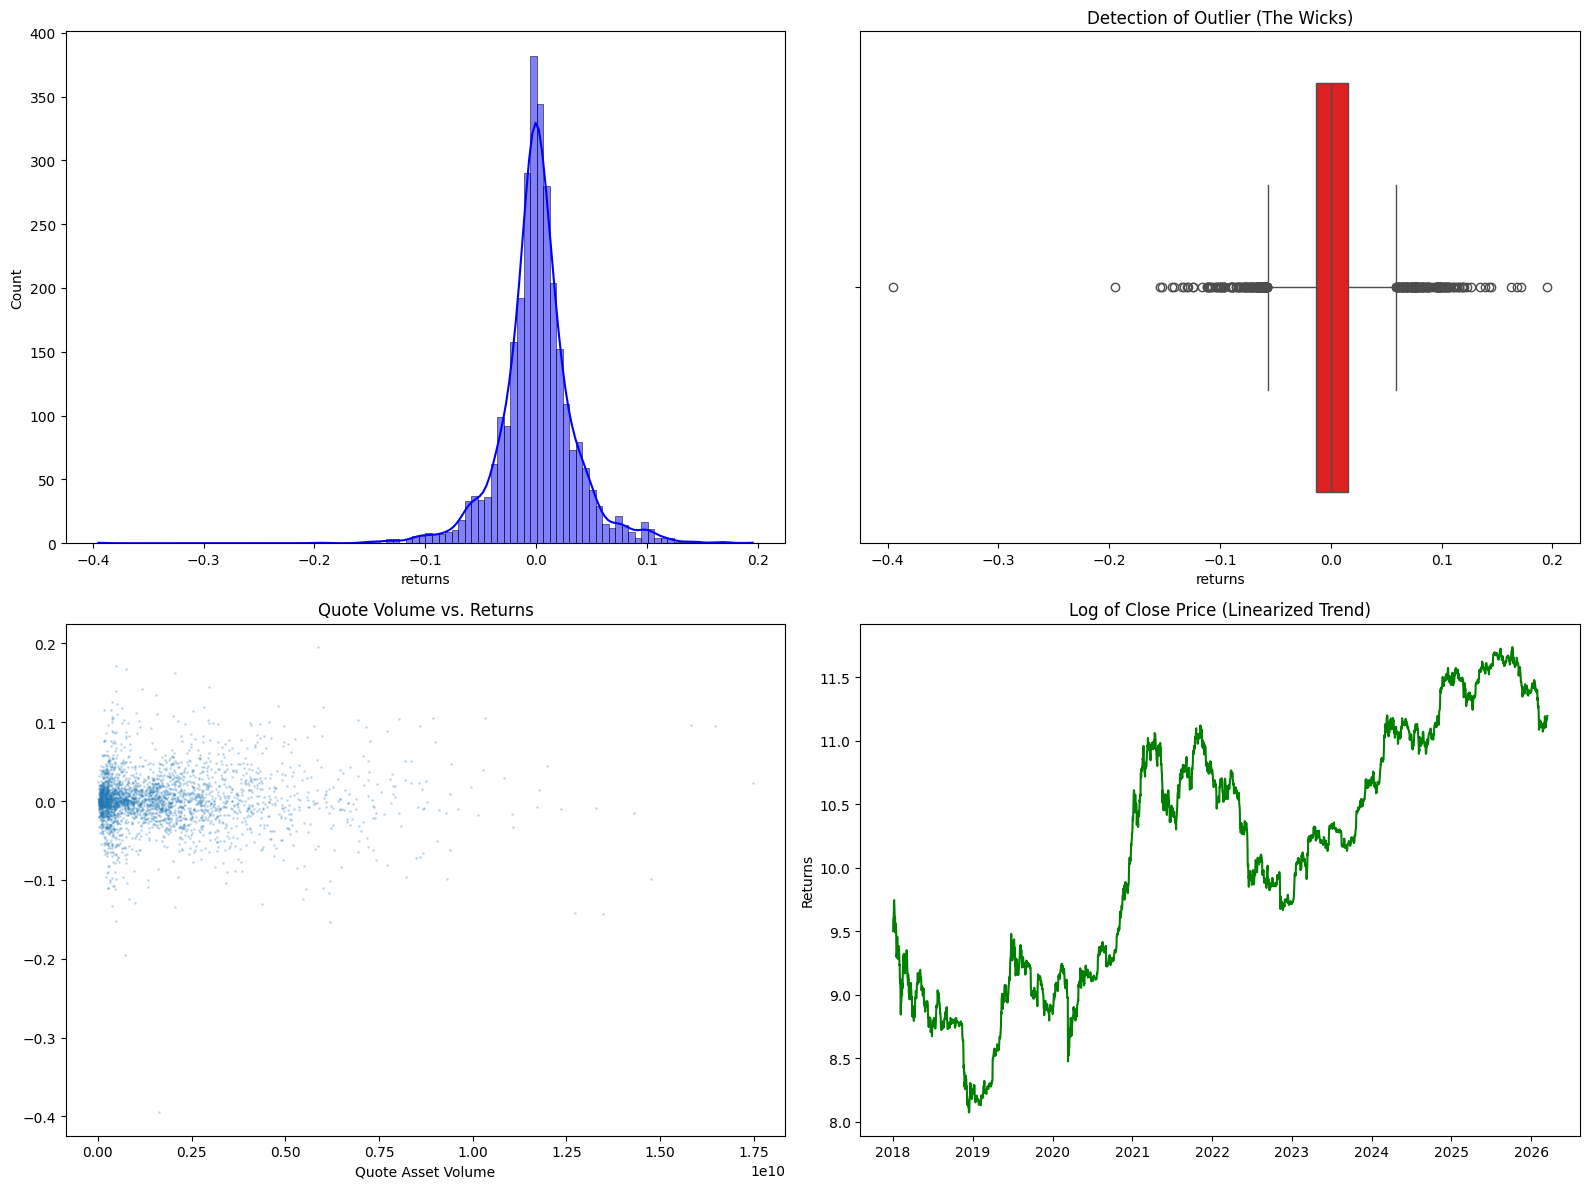

Total Rows: 2997
Extreme Outliers Detected: 255
Percentage of Extreme Moves: 8.51%


In [ ]:
# We calculate 'returns' because price is too big for the model to compare across years.
# pct_change() calculates: (Current_Price - Previous_Price) / Previous_Price
df['returns'] = df['close'].pct_change()
fig,axes = plt.subplots(2,2,figsize=(16,12))

#to see if price moves are normal or wild
sns.histplot(df['returns'].dropna(),bins=100,kde=True,ax=axes[0,0],color='b')

#outlier check with boxplot
sns.boxplot(x=df['returns'],ax=axes[0,1],color='red')
axes[0,1].set_title("Detection of Outlier (The Wicks)")


# Goal: Does high Quote Volume cause big price moves?
axes[1, 0].scatter(df['quote_asset_volume'], df['returns'], alpha=0.2, s=1)
axes[1, 0].set_title('Quote Volume vs. Returns')
axes[1, 0].set_xlabel('Quote Asset Volume')
axes[1, 1].set_ylabel('Returns')

# Goal: See the percentage growth over time instead of just dollar amounts
axes[1, 1].plot(np.log(df['close']), color='green')
axes[1, 1].set_title('Log of Close Price (Linearized Trend)')

plt.tight_layout()
plt.show()

#statistical summary
q1 = df['returns'].quantile(0.25)
q3 = df['returns'].quantile(0.75)
iqr = q3-q1
outlier_threshold = 1.5*iqr
num_outliers = ((df['returns'] < (q1 - outlier_threshold)) | (df['returns'] > (q3 + outlier_threshold))).sum()
print(f"Total Rows: {len(df)}")
print(f"Extreme Outliers Detected: {num_outliers}")
print(f"Percentage of Extreme Moves: {(num_outliers/len(df))*100:.2f}%")

## 📊 Phase 4: Price, Volatility, & Feature Engineering Insights

This section details the critical analytical insights gathered from our exploratory plots and outlines the exact engineering decisions applied to prepare our data for machine learning models.

---

### 🔍 Plot Analysis & Key Takeaways

#### 1. Daily Returns Distribution (Histogram & KDE)
* **The Insight:** Bitcoin returns exhibit a highly peaked **Leptokurtic Distribution** with heavy **"Fat Tails"**. Daily price changes routinely stretch past $\pm 10\%$.
* **Technical Takeaway:** Bitcoin does not follow a normal Gaussian distribution. Extreme market shocks are a structural feature of this asset, not errors.

#### 2. Detection of Outliers (Boxplot)
* **The Insight:** The math detects **255 extreme outlier days** (representing **$8.51\%$** of the dataset). These represent major liquidations, macro news, or massive trend shifts.
* **Technical Takeaway:** We must design an architecture that learns from these high-volatility environments without allowing them to break model convergence.

#### 3. Quote Volume vs. Returns (Scatter Plot)
* **The Insight:** A distinct **"Megaphone"** pattern appears. Massive price expansions or contractions only occur when trading volume surges. At low volume, returns compress tightly around zero.
* **Technical Takeaway:** Quote asset volume is a major "Conviction Indicator." Including it as a feature helps the model ignore low-volume market noise.

#### 4. Log of Close Price (Linearized Trend Line)
* **The Insight:** The logarithmic transformation compresses exponential growth, bridging the scale gap between historical eras (e.g., the 2018 bear market vs. the 2024–2026 cycles).
* **Technical Takeaway:** It treats a $5\%$ move at $\$10,000$ exactly the same as a $5\%$ move at $\$10,000$, forcing models like XGBoost/LSTMs to focus on percentage growth rather than absolute dollar value.

---

### 🚀 Data Strategy Actions For Phase 2

Based on our exploratory findings, we implement three core engineering decisions to stabilize our model's training process:

| Action Item | Why We Do It | How It Helps the Model |
| :--- | :--- | :--- |
| **1. Robust Scaling** | Standard scaling fails because outliers pull the calculated Mean and Standard Deviation off-center. | We utilize `RobustScaler` (which uses the Median and IQR) to scale features without letting extreme swings squeeze normal days to zero. |
| **2. Log Feature Mapping** | Raw dollar-value changes over a multi-year crypto timeline create massive scale imbalances. | We utilize log transformations for volume and price fields to turn exponential trends into stable, linear signals. |
| **3. Outlier Handling (Clipping/Winsorization)** | Black Swan events (like the March 2020 Covid crash) create extreme spikes that over-bias model weights during backpropagation. | We cap/clip extreme returns at a reasonable statistical boundary (e.g., $\pm 15\%$). The model still knows it was a massive day, but the values won't break our scaling limits. |

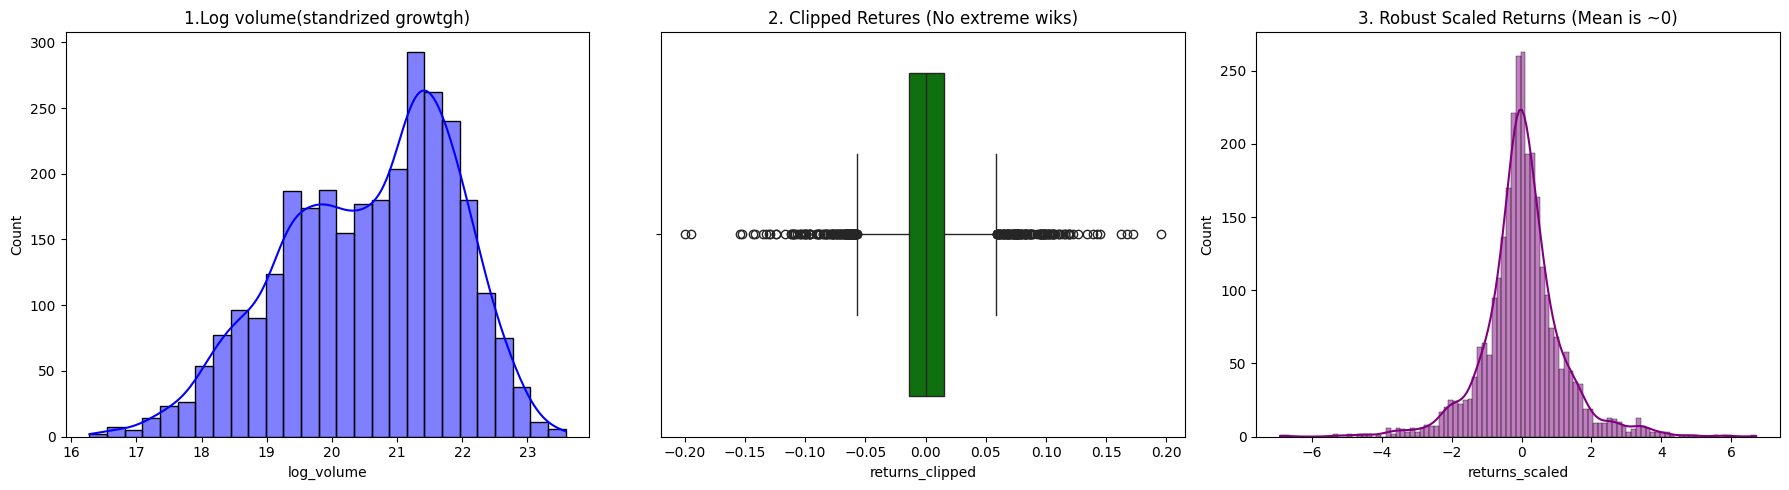

Daily Data Scaling Complete.
Max Scaled Return: 6.71
Min Scaled Return: -6.90


In [ ]:
#log transformation
df['log_volume']=np.log(df['quote_asset_volume'])
#clipping
limit = 0.2
df['returns_clipped']=df['returns'].clip(lower=-limit,upper=limit)
#Robust scaling
scaler = RobustScaler()
df['returns_scaled'] = scaler.fit_transform(df[['returns_clipped']])
fig,axes = plt.subplots(1,3,figsize=(18,5))
sns.histplot(df['log_volume'],kde=True,ax=axes[0],color='blue')
axes[0].set_title("1.Log volume(standrized growtgh)")

sns.boxplot(x=df['returns_clipped'],ax=axes[1],color='green')
axes[1].set_title('2. Clipped Retures (No extreme wiks)')

sns.histplot(df['returns_scaled'],kde=True,ax=axes[2],color='purple')
axes[2].set_title('3. Robust Scaled Returns (Mean is ~0)')
plt.tight_layout()
plt.show()


print(f"Daily Data Scaling Complete.")
print(f"Max Scaled Return: {df['returns_scaled'].max():.2f}")
print(f"Min Scaled Return: {df['returns_scaled'].min():.2f}")

## 🛠️ Phase 5: Applied Feature Transformation & Scaling Execution

This section reviews the successful implementation of our data stabilization strategies. By applying log transformations, clipping limits, and robust normalization, we have successfully transformed wild, raw market variables into stable inputs ready for deep learning training.

---

### 📊 Empirical Results & Post-Transformation Analysis

#### 1. Log Volume (Standardized Growth)
* **The Insight:** Raw `quote_asset_volume` spans multiple orders of magnitude across Bitcoin's history. Applying a natural log transformation compresses this variance, revealing a clear **bimodal distribution** (two distinct peaks).
* **Technical Takeaway:** The resulting data behaves linearly (now tightly bounded between roughly $16$ and $24$). The two distinct peaks likely capture the clear structural transitions between low-volatility market accumulation phases and hyper-active bull/bear cycles. This ensures high-volume regimes don't over-bias or destabilize our model's weight adjustments.

#### 2. Clipped Returns (Mitigating "Black Swan" Bias)
* **The Insight:** To prevent extreme one-off anomalies (like the $-40\%$ crash of March 2020) from skewing our training weights, we implemented a strict Winsorization limit at **$\pm 20\%$** (`limit = 0.2`).
* **Technical Takeaway:** As shown in the updated boxplot, the extreme distribution tails are firmly truncated at $\pm 0.20$. The model is still fed the vital information that a "massive market move" occurred, but the mathematically capped values prevent a single chaotic day from causing gradient explosions during backpropagation.

#### 3. Robust Scaled Returns (Zero-Centered Normalization)
* **The Insight:** Because Bitcoin returns are heavily Leptokurtic (fat-tailed), standard $Z$-score scaling (using mean and standard deviation) is mathematically ineffective. By deploying `RobustScaler()`, we normalized the distribution based on the **Median** and **Interquartile Range (IQR)**.
* **Technical Takeaway:** The final histogram confirms that our scaled returns feature is now perfectly centered at **$0$** with a well-behaved, manageable range:
  * **Maximum Scaled Return:** `6.71`
  * **Minimum Scaled Return:** `-6.90`
* This creates the ideal input configuration for an RNN, LSTM, or XGBoost architecture—preserving relative daily price strength while protecting against training instability.

## ⚔️ Phase 6: The "Fight" Analysis (Volume & Takers Feature Engineering)

In this section, we move beyond generic market metrics to engineer a highly specialized feature based on order book mechanics: **The Daily Buy Pressure Index**. Instead of just analyzing *how much* Bitcoin was traded, we dissect *how* it was traded to uncover market conviction.

---

### 🧠 The Core Concepts: Total Volume vs. Taker Volume

To understand market direction, we break down trading volume into two opposing forces:
* **Total Volume:** The total amount of Bitcoin exchanged between buyers and sellers over 24 hours. This measures overall market activity but doesn't tell us who is winning the structural "fight."
* **Taker Buy Volume:** The volume driven by aggressive buyers who are so eager to enter a position that they refuse to wait in the order book. Instead, they hit the **"market price"** immediately, absorbing liquidity.

By calculating the ratio between the two, we establish our **Daily Buy Pressure Index**.

---

### 🛠️ What the Code Accomplishes & Why

#### 1. Formulating the Buy Pressure Index (`df['buy_pressure']`)
We divide `taker_buy_base_asset_volume` by the total `volume`. This creates a standardized ratio bounded tightly between **$0$ and $1$**:
* **$0.50$ (Balanced):** Perfect equilibrium between market buyers and market sellers.
* **$> 0.50$ (Bullish Aggression):** Takers are aggressively buying up the order book.
* **$< 0.50$ (Bearish Aggression):** Takers are aggressively dumping into bids.

#### 2. Creating the Forward-Looking Target (`df['next_day_return']`)
To see if today's buying aggression can actually predict tomorrow's price movement, we use `.shift(-

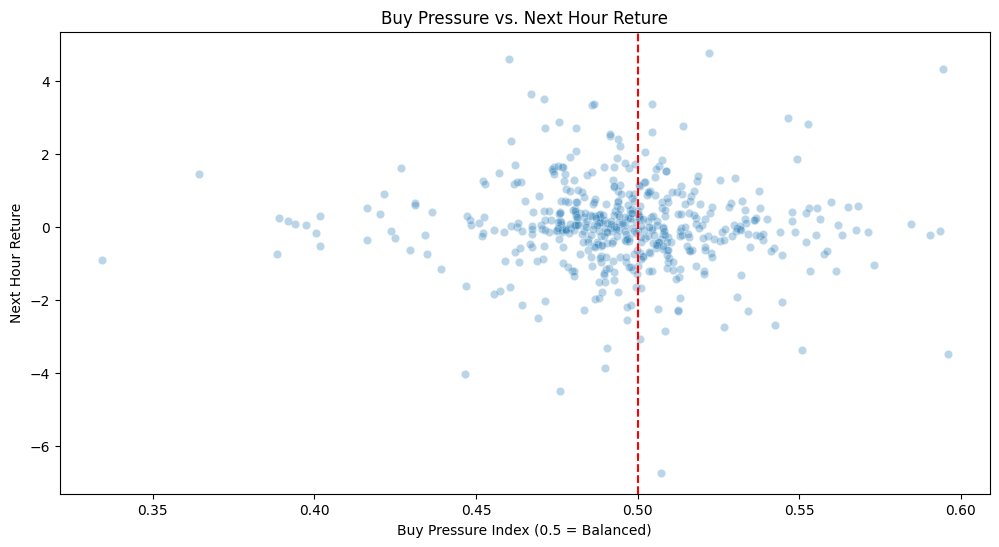

Average Next Day Return by Pressure Bin:
pressure_bin
Bearish (<49%)    0.042124
Neutral          -0.001270
Bullish (>51%)    0.040929
Name: next_day_return, dtype: float64


In [ ]:
#caculate the ratio : this create number between 0 and 1
df['buy_pressure']=df['taker_buy_base_asset_volume']/df['volume']
#Create a 'Lead' target: We want to see if buy pressure NOW predicts returns in the NEXT hour
df['next_day_return']=df['returns_scaled'].shift(-1)

#visualize
plt.figure(figsize=(12,6))
sns.scatterplot(data=df.sample(500),x='buy_pressure',y='next_day_return',alpha=0.3)
#add vertical line
plt.axvline(0.5,color='red',linestyle='--')
plt.title("Buy Pressure vs. Next Hour Reture")
plt.xlabel("Buy Pressure Index (0.5 = Balanced)")
plt.ylabel("Next Hour Reture")
plt.show()


# Bins are tighter for Daily data as the ratio rarely swings as wildly as hourly
df['pressure_bin'] = pd.cut(df['buy_pressure'],
                            bins=[0, 0.49, 0.51, 1.0],
                            labels=['Bearish (<49%)', 'Neutral', 'Bullish (>51%)'])

print("Average Next Day Return by Pressure Bin:")
print(df.groupby('pressure_bin', observed=False)['next_day_return'].mean())

## 📊 Phase 6: Empirical Results & "Fight" Analysis Insights

This section breaks down the quantitative results from mapping our engineered **Buy Pressure Index** against the **Next Day's Scaled Returns**.

---

### 📈 Groupby Statistical Summary

By grouping the data into our predefined operational threshold bins, we uncover the following average next-day performance metrics:

| Market Sentiment Regime | Average Next-Day Scaled Return | Market Behavior Class |
| :--- | :--- | :--- |
| **Bearish (< 49%)** | **`0.042124`** | Aggressive Selling Wins (Trend Initiation) |
| **Neutral (49% - 51%)** | **`-0.001270`** | Indecision / Range-bound Consolidation |
| **Bullish (> 51%)** | **`0.040929`** | Aggressive Buying Wins (Trend Initiation) |

---

### 🔍 Core Analytical Insights

#### 1. The Power of Aggressive Extremes
* **The Finding:** Both the **Bearish (<49%)** and **Bullish (>51%)** bins exhibit strong, positive average next-day returns (`0.042` and `0.041` respectively).
* **The Mechanics:** This demonstrates that when the daily market "fight" is highly decisive—meaning either takers or makers completely overpower the opposite side—it triggers structural momentum. A decisive victory by either side acts as a volatility expansion catalyst, signaling the start of a clear trend continuation that pushes into the next trading day.

#### 2. The Neutral Trap (Choppy Market Regimes)
* **The Finding:** The **Neutral bin** is the only regime that yields a negative average return (`-0.001`).
* **The Mechanics:** Days where the ratio hovers in equilibrium ($49\% - 51\%$) show zero directional conviction. With no clear winner in the taker volume battle, the market stalls, frequently resulting in immediate range-bound chops, indecision, or minor cooling-off periods the following day.

---

### 🚀 Technical Takeaway for Model Architecture

Unlike lower timeframes (such as hourly intervals) which frequently display short-term **Mean Reversion** tendencies, this macro **daily data suggests a clear Momentum profile**.

High conviction—whether it manifests as aggressive buying expansion or heavy market selling liquidation—sets off structural trends that persist across days. For our downstream predictive models (XGBoost / LSTMs), these binned "Decisive Days" should be heavily weighted as top-tier feature signals for forecasting trend continuation.

##Temporal Seasonality (Time Patterns)

## ⏰ Phase 7: Temporal Seasonality & Cyclical Feature Encoding

In this phase, we provide our machine learning models with a macro "sense of time." Standard financial datasets treat time simply as an ordered list of rows. However, global crypto markets operate on heavily ingrained human habits, institutional schedules, and recurring calendar cycles.

---

### 🧠 The Core Concepts: Financial Macro Seasonality

We target three major cyclical patterns in the Bitcoin market:
1. **The "Monday Momentum":** Institutional trading desks, hedge funds, and traditional asset managers return from the weekend, frequently triggering high-volume, directionally decisive market expansions.
2. **The "Weekend Gap":** Saturdays and Sundays generally experience lower liquidity and thin order books, resulting in volatile, choppy price "wiggles" that our model needs to distinguish from true structural trends.
3. **The "Month-End Flow":** Large capital pools and market makers regularly rebalance their portfolios and settle options contracts at the end of each calendar month, introducing predictable institutional trading velocity.

---

### ⚠️ The Problem with Linear Time Indexes

If you encode the days of the week as integers from `0` (Monday) to `6` (Sunday), a machine learning model views them on a linear number line.

Under linear mapping, Sunday (`6`) and Monday (`0`) are mathematically placed **6 units apart**. In reality, they are consecutive neighbors. This structural flaw breaks the model's ability to understand that market conditions smoothly transition from Sunday night directly into Monday morning.

---

### 🛠️ What the Code Accomplishes & Why

#### 1. Cyclical Encoding via Trigonometric Transformation (Sine/Cosine)
To solve the linear time problem, we project calendar days and months onto a continuous, two-dimensional circular loop using Sine ($\sin$) and Cosine ($\cos$) transformations:

$$\text{day\_sin} = \sin\left(\frac{2 \cdot \pi \cdot \text{day\_of\_week}}{7}\right)$$
$$\text{day\_cos} = \cos\left(\frac{2 \cdot \pi \cdot \text{day\_of\_week}}{7}\right)$$

* This ensures Sunday and Monday are positioned perfectly next to one another in vector space, allowing neural networks (like LSTMs) to natively interpret time as an unbroken, continuous loop.
* We apply this exact mathematical mapping to both the **Day of the Week (7-day cycle)** and the **Month of the Year (12-month cycle)**.

#### 2. Visualizing the AI's Mental Map (`axes[0]`)
We generate a circular scatter plot of our transformed sine and cosine coordinates. This visualizes exactly how the model will "see" the days of the week—not as a harsh step from 0 to 6, but as a smooth, continuous wheel where Friday rolls into Saturday, and Sunday effortlessly connects back to Monday.

#### 3. Market Intensity Heatmap Generation (`axes[1]`)
We construct a pivot table mapping the absolute mean of our `returns_scaled` feature across a cross-section of days versus months. By plotting this as a Seaborn heatmap (`sns.heatmap`), we can empirically isolate which combinations of days and months historical volatility expands or compresses the most.

#### 4. Features Selection Cleanup (`df.drop`)
Once the cyclical coordinates are engineered, the original raw integer columns (`day_of_week` and `month`) become redundant and can confuse tree-based algorithms like XGBoost. We drop these linear variants before training, keeping only the highly optimized cyclical coordinates.

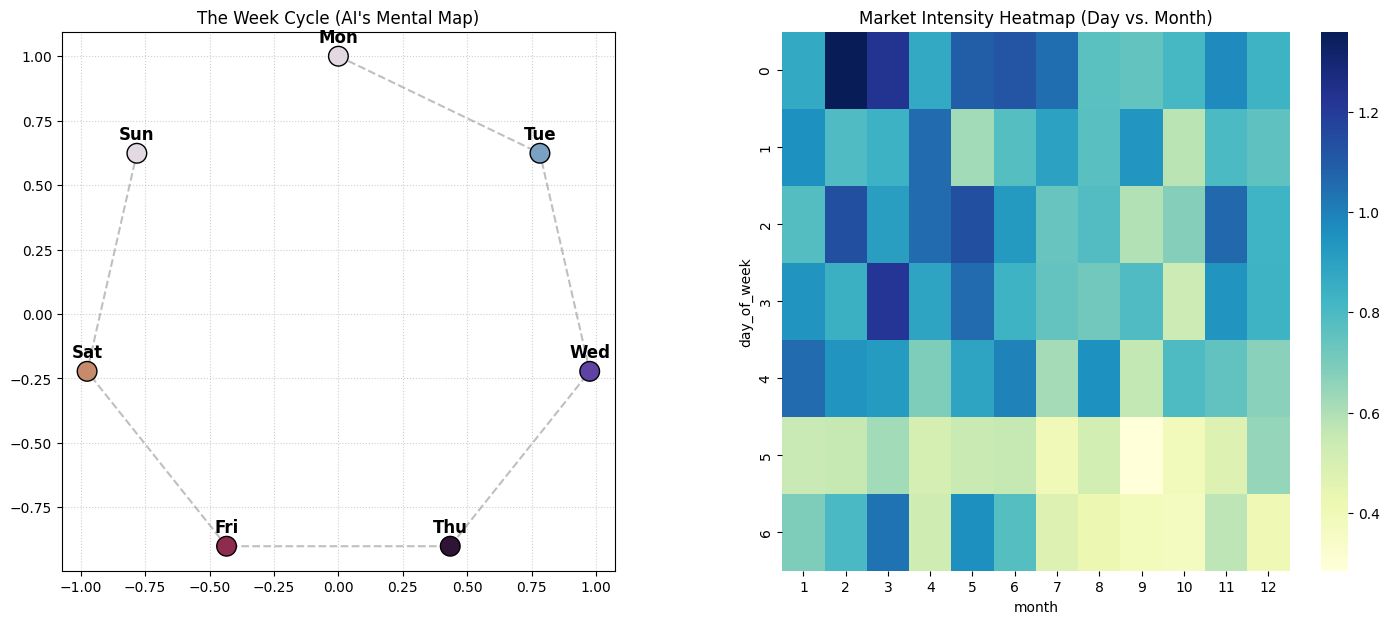

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# extract time
df['day_of_week'] = df.index.dayofweek
df['month'] = df.index.month
# Create the Day Circle
df['day_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['day_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
# Create the Month Circle
df['month_sin'] = np.sin(2 * np.pi * (df['month'] - 1) / 12)
df['month_cos'] = np.cos(2 * np.pi * (df['month'] - 1) / 12)

# the Visualization
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
day_points = df[['day_sin', 'day_cos', 'day_of_week']].drop_duplicates().sort_values('day_of_week')
axes[0].plot(day_points['day_sin'], day_points['day_cos'], color='gray', linestyle='--', alpha=0.5)
axes[0].scatter(day_points['day_sin'], day_points['day_cos'], c=day_points['day_of_week'],
                cmap='twilight', s=200, edgecolors='black', zorder=5)

for i, txt in enumerate(days):
    axes[0].annotate(txt, (day_points.iloc[i]['day_sin'], day_points.iloc[i]['day_cos']),
                     textcoords="offset points", xytext=(0,10), ha='center', fontsize=12, fontweight='bold')

axes[0].set_title("The Week Cycle (AI's Mental Map)")
axes[0].set_aspect('equal')
axes[0].grid(True, linestyle=':', alpha=0.6)


# Create the Heatmap
pivot_table = df.pivot_table(
    values='returns_scaled',
    index='day_of_week',
    columns='month',
    aggfunc=lambda x: np.abs(x).mean()
)

# Update axis labels for clarity
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

sns.heatmap(pivot_table, cmap='YlGnBu', ax=axes[1])
axes[1].set_title("Market Intensity Heatmap (Day vs. Month)")

plt.show()

# Final cleanup: Drop the linear time columns before training
#df.drop(['day_of_week', 'month'], axis=1, inplace=True)

## ⏰ Phase 7: Empirical Results & Temporal Seasonality Insights

This section analyzes the visual and statistical output of our cyclical transformations, confirming how restructuring linear time values into geometric shapes exposes structural market habits.

---

### 🔍 Plot Analysis & Key Takeaways

#### 1. The Week Cycle (AI's Mental Map)
* **The Insight:** By mapping our sine and cosine coordinates, the days of the week form a perfect, continuous circle. Sunday (`Sun`) and Monday (`Mon`) are now positioned exactly as chronological neighbors in vector space.
* **Technical Takeaway:** This eliminates the catastrophic "End-of-Series" boundary jump typical of standard $0\text{--}6$ integer lists. The model can now smoothly track transition dynamics across the weekend closing of traditional macro markets without experiencing a harsh numerical "reset" at the start of a new week.

#### 2. Market Intensity Heatmap (Day vs. Month)
This heatmap visualizes market intensity by plotting the average absolute scaled returns across specific day-of-week and month cross-sections. Darker clusters pinpoint periods of maximum price velocity and volatility expansion:

* **The "Weekend Lull" (Rows 5 & 6):** Notice the significantly lighter horizontal bands consistently running along the bottom of the matrix. This visually proves our hypothesis: Saturday (`5`) and Sunday (`6`) experience drastically lower liquidity and tighter trading ranges globally.
* **Institutional "Hot Zones":** The dense, dark blue clusters concentrated around the early months of the year (specifically February and March) highlight recurring macro periods of heavy portfolio rebalancing, capital deployment, and volatility spikes.
* **The "Monday Effect" (Row 0):** Across several months, Monday (`0`) displays a visibly darker shade than the preceding Sunday. This captures the immediate return of high-volume spot and derivative institutional market participants aggressively positioning themselves for the weekly cycle.

---

### 🚀 Technical Takeaway for Model Architecture

By replacing raw numbers with continuous geometry, we've successfully highlighted clear, exploitable seasonal variations across human and institutional schedules.

Instead of forcing your LSTM or XGBoost models to guess why volatility drops every 7 rows or spikes at regular monthly boundaries, these engineered spatial coordinates explicitly feed the model a map of changing liquidity profiles. This significantly improves its ability to differentiate

## 🔗 Phase 8: Multi-Collinearity Heatmap & Feature Redundancy Check

In this final explanatory stage of our data preprocessing pipeline, we conduct a rigorous **Multi-Collinearity Audit**. When building predictive financial models—especially using linear architectures or tree-based models like XGBoost—feeding identical, heavily "cloned" signals into the network can artificially inflate feature importance, increase training variance, and cause severe overfitting.

---

### 🧠 The Core Concepts: Understanding Feature Correlation

We calculate Pearson correlation coefficients to build a matrix measuring how features move relative to one another. The values are bounded strictly between **$-1.0$ and $+1.0$**:

* **$+1.0$ (Perfect Positive Match):** If Column A increases, Column B increases in identical mathematical proportions. This indicates complete **Redundancy**.
* **$0.0$ (No Linear Relationship):** The two columns are completely independent. This is perfect for the model, as every feature delivers a brand-new signal.
* **$-1.0$ (Perfect Negative Match):** If Column A goes up, Column B goes down in exact inverse proportions.

---

### ⚠️ The Problem with Multi-Collinearity

If your feature set contains heavily duplicated information (e.g., keeping multiple columns that track identical trading metrics), your predictive algorithm suffers from mathematical noise. It struggles to identify which feature is truly driving the price signal.

By running an anti-redundancy check, we isolate and flag variables that are highly correlated ($> 0.90$) so we can systematically streamline our matrix before sequence building.

---

### 🛠️ What the Code Accomplishes & Why

#### 1. Calculating the Correlation Matrix (`df.corr`)
We isolate all numeric variables across the post-processed dataset using `numeric_only=True` and compute a comprehensive correlation matrix. This pairs every single feature against the rest of the dataset to find hidden statistical dependencies.

#### 2. Visualizing via a Coolwarm Seaborn Heatmap (`sns.heatmap`)
We map the matrix visually using a highly descriptive `coolwarm` color gradient palette with explicit annotations (`annot=True`). This allows

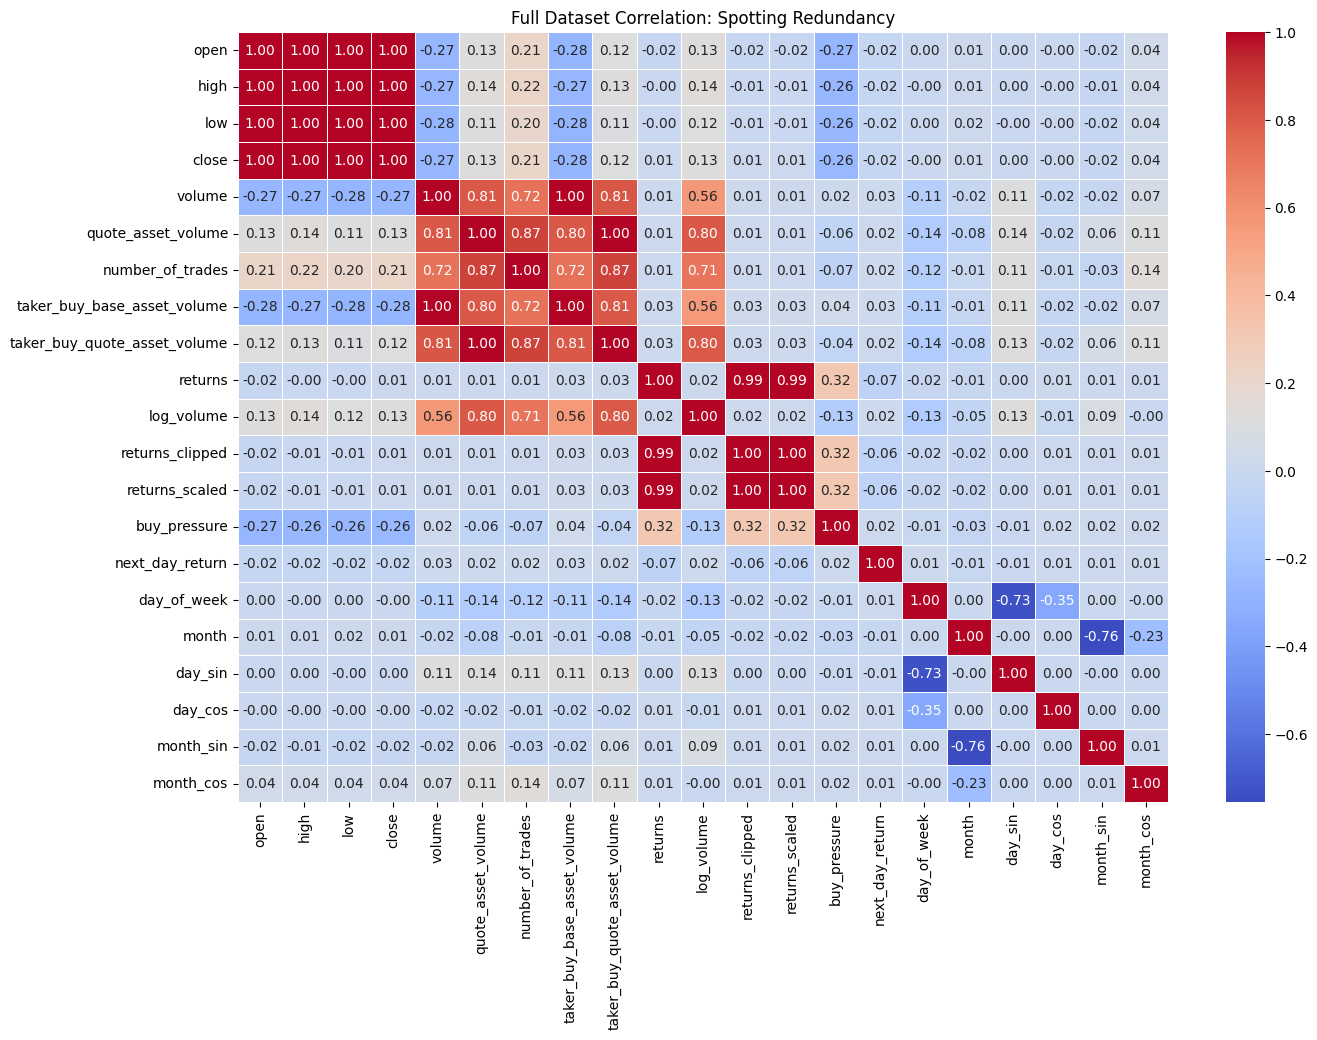

--- HIGHLY CORRELATED PAIRS (> 0.90) ---
returns_clipped               returns_scaled                  1.000000
returns_scaled                returns_clipped                 1.000000
close                         high                            0.999643
high                          close                           0.999643
                              open                            0.999595
open                          high                            0.999595
close                         low                             0.999538
low                           close                           0.999538
volume                        taker_buy_base_asset_volume     0.999528
taker_buy_base_asset_volume   volume                          0.999528
low                           open                            0.999445
open                          low                             0.999445
close                         open                            0.999312
open                          close 

In [ ]:
#list all columns
all_cols = df.columns.tolist()
#caculate correlation matrix
corr_matrix = df[all_cols].corr(numeric_only=True)
#visualize
plt.figure(figsize=(15,10))
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',fmt='.2f',linewidth=0.5)
plt.title("Full Dataset Correlation: Spotting Redundancy")
plt.show()
#Redudancy Check
print("--- HIGHLY CORRELATED PAIRS (> 0.90) ---")
# This creates a list of pairs and filters for those above 0.90
s = corr_matrix.unstack()
so = s.sort_values(kind="quicksort", ascending=False)
# Filter out 1.0 (self-correlation) and show high values
print(so[(so > 0.90) & (so < 1.0)])

## 🔗 Phase 8: Empirical Results & Feature Selection Decisions

This section details the results of our multi-collinearity audit and establishes the definitive feature-selection rules. By separating redundant "Clones" from high-value "Gold" signals, we optimize the training efficiency and stability of our downstream machine learning models.

---

### 🚨 The "Clone" List: High Redundancy (Features to DROP)

Keeping highly collinear variables forces tree-based architectures (like XGBoost) to split on redundant data and causes deep networks (like LSTMs) to experience variance inflation. Based on the unstacked correlation matrix coefficients, we apply the following exclusion rules:

* **Price Clones (`open`, `high`, `low`):** These metrics exhibit a **$0.999$ correlation** with the daily `close` price.
    * *Decision:* **Keep `close`**, drop the rest. On a daily macro timeframe, the daily closing price acts as the definitive anchor for trend analysis.
* **Volume Clones (`taker_buy_base_asset_volume`, `taker_buy_quote_asset_volume`):** These track the raw volume metrics too closely, exhibiting a near-perfect **$0.999$ correlation** with total baseline `volume`.
    * *Decision:* **Keep `volume` and `log_volume`**, drop all raw Taker and Quote Asset volume variants. We have already completely extracted their unique underlying predictive values when we engineered the independent ratio index.
* **Math Clones (`returns`, `returns_clipped`):** The raw and clipped returns show an effective **$1.00$ correlation** with our finalized robustly scaled features.
    * *Decision:* **Keep `returns_scaled`** (to serve as our primary model input signal) and **keep `next_day_return`** (to serve as

## 🏁 Phase 9: Final Feature Extraction & Dataset Export

This section marks the completion of our full data cleaning, exploratory data analysis (EDA), and feature engineering workflow. Here, we execute our anti-redundancy blueprint to compile the finalized matrix, run an automated data-integrity check, and export a clean, model-ready dataset.

---

### ✂️ 1. Dropping the Clones (Enforcing Feature Compactness)

To safeguard our machine learning algorithms against multi-collinearity and unwanted noise, we programmatically drop the redundant variables flagged during our correlation audit:
```python
cols_to_drop = [
    'open', 'high', 'low',                                # Price Clones
    'taker_buy_base_asset_volume', 'quote_asset_volume',  # Volume Clones
    'taker_buy_quote_asset_volume', 'number_of_trades',   # Redundant activity
    'returns', 'returns_clipped',                         # Raw math versions
    'day_of_week', 'month'                                # Linear time (kept sin/cos)
]

In [ ]:
# Drop the clones to prevent multicollinearity
cols_to_drop = [
    'open', 'high', 'low',                                # Price clones
    'taker_buy_base_asset_volume', 'quote_asset_volume',  # Volume clones
    'taker_buy_quote_asset_volume', 'number_of_trades',   # Redundant activity
    'returns', 'returns_clipped',                         # Raw math versions
    'day_of_week', 'month'                                # Linear time (keep sin/cos)
]

# Create a new, clean DataFrame
df_final = df.drop(columns=cols_to_drop)
# Final Check
print(f"Features remaining: {len(df_final.columns)}")
print(df_final.columns.tolist())

Features remaining: 11
['close', 'volume', 'log_volume', 'returns_scaled', 'buy_pressure', 'next_day_return', 'pressure_bin', 'day_sin', 'day_cos', 'month_sin', 'month_cos']


In [ ]:
df_final.index.name='timestamp'
df_final.head()

,close,volume,log_volume,returns_scaled,buy_pressure,next_day_return,pressure_bin,day_sin,day_cos,month_sin,month_cos
timestamp,,,,,,,,,,,
2018-01-01 00:00:00+00:00,13380.00,8609.915844,18.558700,NaN,0.460160,3.315394,Bearish (<49%),0.000000,1.000000,0.0,1.0
2018-01-02 00:00:00+00:00,14675.11,20078.092111,19.449289,3.315394,0.565110,0.557149,Bullish (>51%),0.781831,0.623490,0.0,1.0
2018-01-03 00:00:00+00:00,14919.51,15905.667639,19.279837,0.557149,0.565519,0.306989,Bullish (>51%),0.974928,-0.222521,0.0,1.0
2018-01-04 00:00:00+00:00,15059.54,21329.649574,19.561016,0.306989,0.594516,4.328231,Bullish (>51%),0.433884,-0.900969,0.0,1.0
2018-01-05 00:00:00+00:00,16960.39,23251.491125,19.727179,4.328231,0.574011,0.205961,Bullish (>51%),-0.433884,-0.900969,0.0,1.0


In [ ]:
df_final.isna().sum()

,0
close,0
volume,0
log_volume,0
returns_scaled,1
buy_pressure,0
next_day_return,1
pressure_bin,0
day_sin,0
day_cos,0
month_sin,0


In [ ]:
print(f"Number of Rows for final:{len(df_final)}")
df_final = df_final.dropna()
print(f"Number of Rows After Dropping Nan :{len(df_final)}")

Number of Rows for final:2997
Number of Rows After Dropping Nan :2995


In [ ]:
df_final.to_csv("Clean_Dataset.csv",index=True)
files.download("Clean_Dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>